# Exercise 1: Linear and Logistic Regression with Error Estimation


## Instructions






### Setup check

Run the cell below before you begin. Every entry should report `found`.

In [ ]:
import os
import sys

print("Python", sys.version.split()[0])

for package in ["numpy", "pandas", "matplotlib", "seaborn", "sklearn"]:
    try:
        __import__(package)
        print(f"{package:<12} found")
    except ImportError:
        print(f"{package:<12} MISSING  ->  pip install {package}")

for filename in ["headbrain.csv", "titanic.csv", "diabetes.csv"]:
    path = os.path.join("/content", filename)
    status = "found" if os.path.isfile(path) else "MISSING"
    print(f"{filename:<16} {status}")

Python 3.12.13
numpy        found
pandas       found
matplotlib   found
seaborn      found
sklearn      found
headbrain.csv    found
titanic.csv      found
diabetes.csv     found


---
# Part A. Linear regression

## Program 1. Ordinary least squares regression, from first principles and with `scikit-learn`

### Aim

To implement simple linear regression in Python without a machine learning library, to reproduce
the same fit using `scikit-learn`, and to attach an uncertainty estimate to the fitted
coefficients.

### Theory

The regression line is written as $y = b_0 + b_1 x$. The least squares estimates of the two
coefficients are

$$
\newcommand{\vect}{\mathbf}
\begin{align}
b_1 &= \frac{\displaystyle \sum_{i=1}^{m}(x_i-\bar{x})(y_i-\bar{y})}{\displaystyle \sum_{i=1}^{m}(x_i-\bar{x})^2}
= \frac{(\vect{x}-\bar{x})^T(\vect{y}-\bar{y})}{(\vect{x}-\bar{x})^T(\vect{x}-\bar{x})}
\\
b_0 &= \bar{y}-b_1\bar{x}
\end{align}
$$

The quality of the fit is summarised by

$$
\begin{align}
\text{RMSE} &= \sqrt{\frac{1}{m}\sum_{i=1}^{m}(y_i-\hat{y_i})^2}
= \sqrt{\frac{(\vect{y}-\hat{\vect{y}})^T(\vect{y}-\hat{\vect{y}})}{m}}
\\
\text{SS}_{\text{tot}} &= \sum_{i=1}^{m}(y_i - \bar{y})^2 = (\vect{y}-\bar{y})^T(\vect{y}-\bar{y})
\\
\text{SS}_{\text{res}} &= \sum_{i=1}^{m}(y_i - \hat{y}_i)^2 = (\vect{y}-\hat{\vect{y}})^T(\vect{y}-\hat{\vect{y}})
\\
R^{2} &= 1-\frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}
\end{align}
$$

where $\vect{x} = (x_1,x_2,\dots,x_m)$ is the input vector, $\vect{y} = (y_1,y_2,\dots,y_m)$ is the
output vector, $\bar{x}$ and $\bar{y}$ are the corresponding means, and
$\hat{\vect{y}} = (\hat{y}_1,\hat{y}_2,\dots,\hat{y}_m)$ is the vector of predicted values.

Under the usual assumption of independent errors of constant variance, the standard errors of the
two coefficients follow from the residual variance
$s^2 = \text{SS}_{\text{res}}/(m-2)$:

$$
\begin{align}
\text{SE}(b_1) &= \sqrt{\frac{s^2}{\sum_{i=1}^{m}(x_i-\bar{x})^2}}
\\
\text{SE}(b_0) &= \sqrt{s^2\left[\frac{1}{m} + \frac{\bar{x}^2}{\sum_{i=1}^{m}(x_i-\bar{x})^2}\right]}
\end{align}
$$

The divisor $m-2$ appears because two parameters have already been estimated from the same data.

### TASK A1. Implementing the regression class

Complete the three methods of the class below. Use vectorised NumPy operations only, without an
explicit Python loop over the samples, and without importing `scikit-learn`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
class LinearRegression:
    """Simple linear regression by ordinary least squares."""

    def fit(self, X, y):
        """Estimate b0 and b1 from one-dimensional arrays X and y.

        Stores the results as self.b0 and self.b1 and returns self.
        """
        m = X.shape[0]
        x_mean, y_mean = X.mean(), y.mean()
        xc, yc = X - x_mean, y - y_mean
        self.b1 = (xc @ yc) / (xc @ xc)
        self.b0 = y_mean - self.b1 * x_mean
        print(f"(b0, b1) = ({self.b0:.3f}, {self.b1:.3f})")
        return self


    def predict(self, X):
        """Return the predicted response for the array X."""
        return self.b0 + self.b1 * np.asarray(X).ravel()

    def evaluate(self, X, y):
        """Print and return the RMSE and the R^2 score as a tuple."""

        y_pred = self.predict(X)
        res = y - y_pred
        rmse = np.sqrt((res @ res) / y.shape[0])
        ss_res = res @ res
        ss_tot = (y - y.mean()) @ (y - y.mean())
        r2 = 1 - ss_res / ss_tot
        print("Root mean squared error:", round(rmse, 3))
        print("R^2 value:", round(r2, 3))
        return rmse, r2

### TASK A2. Plotting the fit

Complete the plotting helper. The scatter of the observed data and the fitted straight line must
appear on the same axes.

def regression_plot(X, y, model, title=""):
    """Scatter plot of the data with the fitted regression line drawn over it."""
    plt.figure(figsize=(10, 6))
    plt.title(title)

    # TODO
    # 1. label the x axis as "Head size (cm^3)" and the y axis as "Brain weight (grams)"
    # 2. build a two-element array x_line spanning slightly beyond the data range,
    #    shaped as a column so that both implementations of predict() accept it
    # 3. evaluate the model on x_line to obtain y_line
    # 4. draw the observed points with plt.scatter and the fitted line with plt.plot
    # 5. add a legend and show the figure

    raise NotImplementedError("Task A2: complete regression_plot(), then delete this line")

In [ ]:
def regression_plot(X, y, model, title=""):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Head size (cm^3)")
    plt.ylabel("Brain weight (grams)")
    x_line = np.array([[X.min() * 0.95], [X.max() * 1.05]])
    y_line = np.ravel(model.predict(x_line))
    plt.scatter(X, y, s=12, label="Observed")
    plt.plot(x_line.ravel(), y_line, color="red", label="Fitted line")
    plt.legend()
    plt.show()

### TASK A3. Fitting the head and brain dataset

The dataset relates the head size of an adult to the mass of the brain. Load it, extract the two
columns of interest, fit the model, plot the result, and evaluate the fit.

In [ ]:
data = pd.read_csv("headbrain.csv")
print(data.shape)
data.head()

(237, 4)


,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
0,1,1,4512,1530
1,1,1,3738,1297
2,1,1,4261,1335
3,1,1,3777,1282
4,1,1,4177,1590


In [ ]:
# TODO : extract the predictor and the response as one-dimensional NumPy arrays
X = data["Head Size(cm^3)"].values
y = data["Brain Weight(grams)"].values

(b0, b1) = (325.573, 0.263)


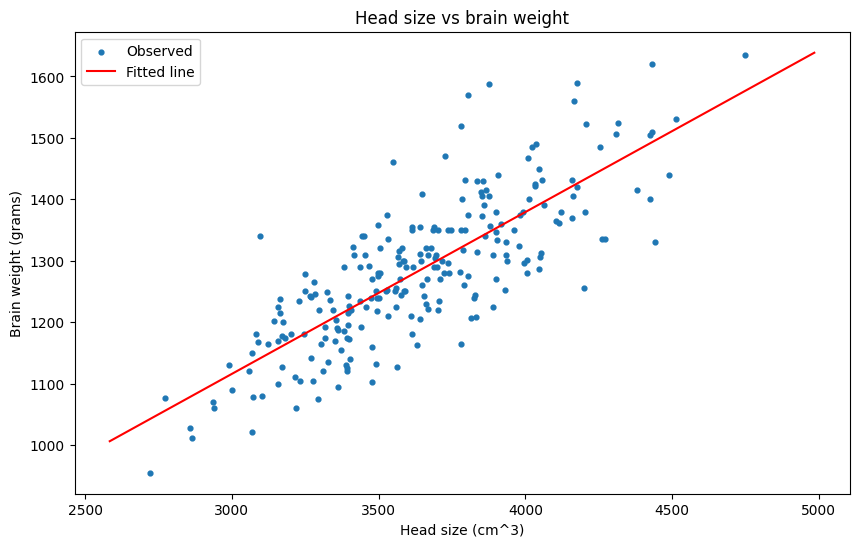

Root mean squared error: 72.121
R^2 value: 0.639


(np.float64(72.1206213783709), np.float64(0.6393117199570002))

In [ ]:
# TODO : create the model, fit it, plot the fit, and evaluate it
model = LinearRegression().fit(X, y)
regression_plot(X, y, model, title="Head size vs brain weight")
model.evaluate(X, y)

### TASK A4. Comparison with `scikit-learn`

Repeat the fit with the library estimator and confirm that the two implementations agree.

Note that `scikit-learn` expects a two-dimensional array of predictors, so the input has to be
reshaped from `(m,)` to `(m, 1)`.

In [ ]:
from sklearn.linear_model import LinearRegression as SkLinearRegression
from sklearn.metrics import mean_squared_error

X1 = X.reshape(-1, 1)

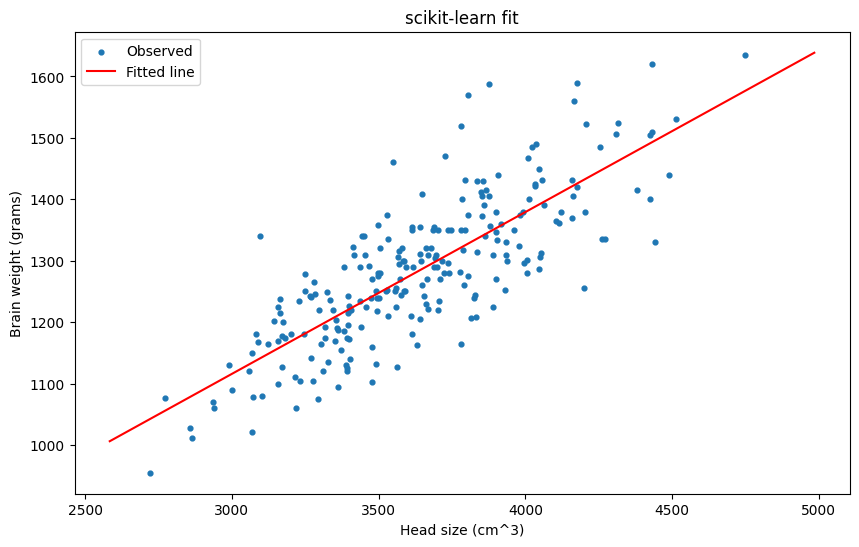

Intercept: 325.573 Coefficient: 0.263
RMSE: 72.121
R^2: 0.639
|db0| = 2.2737367544323206e-13 |db1| = 5.551115123125783e-17


In [ ]:
# TODO
# 1. fit SkLinearRegression on X1 and y
# 2. reuse regression_plot to display the fit
# 3. print the intercept and the coefficient, the RMSE, and the R^2 score
# 4. print the absolute difference between your own b0, b1 and the library values

sk = SkLinearRegression().fit(X1, y)
regression_plot(X, y, sk, title="scikit-learn fit")
y_pred = sk.predict(X1)
print("Intercept:", round(sk.intercept_, 3), "Coefficient:", round(sk.coef_[0], 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y, y_pred)), 3))
print("R^2:", round(sk.score(X1, y), 3))
print("|db0| =", abs(model.b0 - sk.intercept_), "|db1| =", abs(model.b1 - sk.coef_[0]))

### TASK A5. Error estimation

A coefficient reported without an uncertainty is of limited scientific value. In this task the
uncertainty is estimated in two independent ways, first from the analytical expressions given in
the theory section and then by resampling.

The 95 per cent confidence interval of a coefficient is approximated as
$b \pm t_{0.975,\,m-2}\,\text{SE}(b)$, where the critical value is close to 1.96 for a sample of
this size.

In [ ]:
def coefficient_standard_errors(X, y, model):
    # Return (se_b0, se_b1) for a fitted simple linear regression model.

    # TODO
    # 1. obtain the residuals y - model.predict(X)
    # 2. compute the residual variance s^2 with the correct number of degrees of freedom
    # 3. compute the two standard errors from the expressions in the theory section

    m = X.shape[0]
    res = y - model.predict(X)
    s2 = (res @ res) / (m - 2)
    sxx = ((X - X.mean()) ** 2).sum()
    return np.sqrt(s2 * (1 / m + X.mean() ** 2 / sxx)), np.sqrt(s2 / sxx)


se_b0, se_b1 = coefficient_standard_errors(X, y, model)
t = 1.96
print(f"b0 = {model.b0:.3f} +/- {se_b0:.3f}  CI [{model.b0-t*se_b0:.3f}, {model.b0+t*se_b0:.3f}]")
print(f"b1 = {model.b1:.3f} +/- {se_b1:.3f}  CI [{model.b1-t*se_b1:.3f}, {model.b1+t*se_b1:.3f}]")


# TODO: report b0 and b1 together with their standard errors and their 95 per cent
# confidence intervals, in the form  b1 = 0.263 +/- 0.010

b0 = 325.573 +/- 47.141  CI [233.177, 417.969]
b1 = 0.263 +/- 0.013  CI [0.238, 0.289]


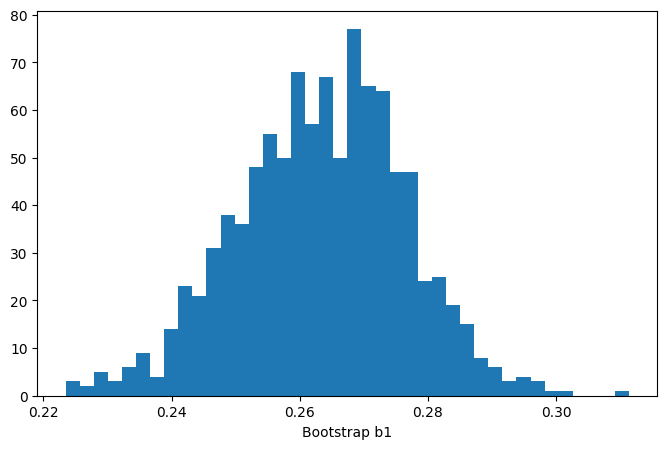

Bootstrap SD: 0.0132 Analytical SE(b1): 0.0129


In [ ]:
def bootstrap_slope(X, y, n_resamples=1000, seed=0):
    # Return an array of slope estimates from n_resamples bootstrap replicates.
    rng = np.random.default_rng(seed)

    # TODO
    # 1. draw an index array of size m with replacement using rng.integers
    # 2. fit the model to the resampled data and store the slope
    # 3. repeat n_resamples times and return the collected slopes

    m = X.shape[0]
    slopes = np.empty(n_resamples)
    for i in range(n_resamples):
        idx = rng.integers(0, m, m)
        xb, yb = X[idx], y[idx]
        xc, yc = xb - xb.mean(), yb - yb.mean()
        slopes[i] = (xc @ yc) / (xc @ xc)
    return slopes

# TODO: plot a histogram of the bootstrap slopes, print their standard deviation,
# and compare it with the analytical SE(b1) obtained above. Comment on the agreement.
slopes = bootstrap_slope(X, y)
plt.figure(figsize=(8, 5))
plt.hist(slopes, bins=40)
plt.xlabel("Bootstrap b1")
plt.show()
print("Bootstrap SD:", round(slopes.std(ddof=1), 4), "Analytical SE(b1):", round(se_b1, 4))

### TASK A6. Written questions

Answer in the cell below.

1. The fitted slope carries physical units. State them and explain in one sentence what the slope
   means for this dataset.
2. The value of $R^2$ obtained here is well below unity. Give two distinct reasons why a single
   predictor cannot account for all of the variance in the response.
3. Suppose the head size were reported in cubic metres instead of cubic centimetres. State how
   $b_0$, $b_1$, RMSE, and $R^2$ would each change.

**ANSWER A6**

1. The slope has units of grams per cubic centimetre (g/cm³). The fitted value b₁ = 0.263 g/cm³ means that, across this sample, each additional cubic centimetre of head size corresponds on average to about 0.263 grams more brain weight.
2. (a) Omitted variables - brain weight also depends on sex, age range, and overall body size, all of which are present in the file but excluded from the model, so their contribution to the variance is left in the residual. (b) Irreducible noise and model form - head size is only an outer proxy for brain volume (skull thickness, cranial shape and measurement error break the link), and the true relationship need not be exactly a straight line, so no single-predictor linear model can drive SS_res to zero. This is why R² = 0.639 rather than ≈1: head size explains about 64% of the variance and 36% is left unexplained.
3. Writing head size in m³ divides every xᵢ by 10⁶, so:
b₁ is multiplied by 10⁶ (0.263 → 2.63×10⁵ g/m³) — and SE(b₁) scales identically, so the ratio b₁/SE(b₁) is unchanged.
b₀ is unchanged (325.573 g), since b₀ = ȳ − b₁x̄ and the product b₁x̄ is invariant.
RMSE is unchanged (72.121 g) — the fitted values ŷ are identical, so the residuals are identical.
R² is unchanged (0.639) — it is dimensionless and invariant under any linear rescaling of the predictor.
In short, only the slope's numerical value and units change; the fit itself is identical.


---
# Part B. Logistic regression

## Program 1. Preprocessing and classification on the Titanic dataset with `scikit-learn`

### Aim

To prepare a dataset that contains missing values and categorical columns, and to fit and evaluate
a logistic regression classifier on it.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic_df = pd.read_csv("titanic.csv")
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### TASK B1. Exploratory visualisation

The helper below draws a single titled figure. Use it to produce the six plots listed in the
comments.

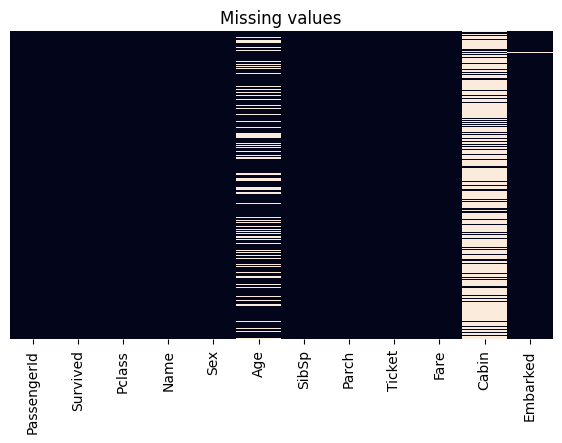

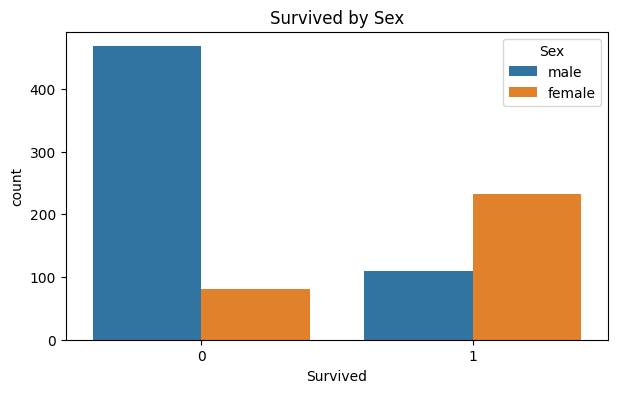

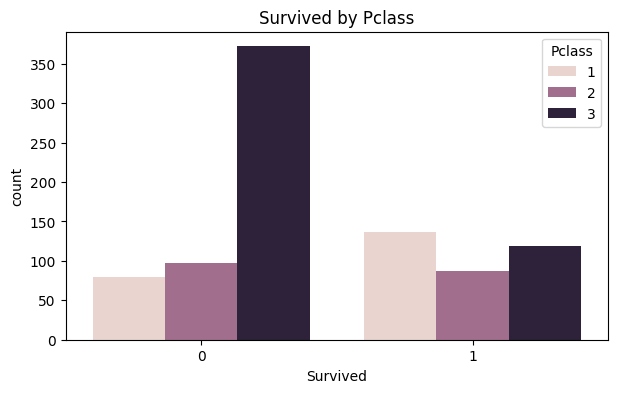

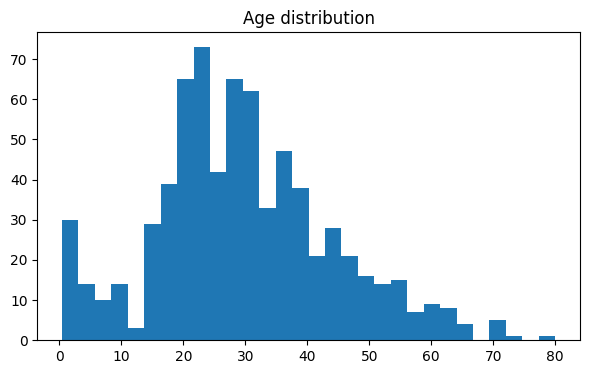

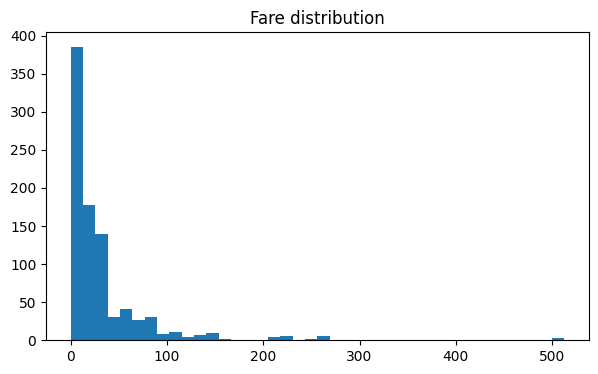

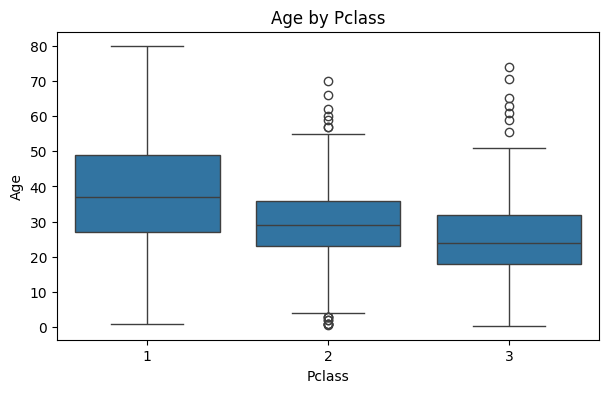

In [ ]:
def plot(title, plot_func, *args, **kwargs):
    plt.figure(figsize=(7, 4))
    plt.title(title)
    plot_func(*args, **kwargs)
    plt.show()


# TODO : produce the following six figures using the helper above
# 1. a heatmap of titanic_df.isnull() to reveal which columns carry missing values
# 2. a count plot of Survived split by Sex
# 3. a count plot of Survived split by Pclass
# 4. a histogram of Age, with the missing entries dropped
# 5. a histogram of Fare
# 6. a box plot of Age against Pclass
plot("Missing values", sns.heatmap, titanic_df.isnull(), yticklabels=False, cbar=False)
plot("Survived by Sex", sns.countplot, data=titanic_df, x="Survived", hue="Sex")
plot("Survived by Pclass", sns.countplot, data=titanic_df, x="Survived", hue="Pclass")
plot("Age distribution", plt.hist, titanic_df["Age"].dropna(), bins=30)
plot("Fare distribution", plt.hist, titanic_df["Fare"], bins=40)
plot("Age by Pclass", sns.boxplot, data=titanic_df, x="Pclass", y="Age")


**ANSWER B1.** State which columns carry missing values, and describe in two or three sentences
what the box plot of age against passenger class reveals.

Three columns carry missing values: Cabin (missing for the large majority of passengers, ~687 of 891), Age (~177 missing), and Embarked (2 missing). Everything else is complete, as the solid bands in the heatmap show.

The box plot of Age against Pclass shows a clear monotone relationship: first-class passengers are oldest (median ≈ 37), second class intermediate (≈ 29), and third class youngest (≈ 24), with third class also containing the most children and the tightest lower quartile. Because age and class are correlated in this way, filling missing ages with the overall column mean (≈ 29.7) would systematically overstate the age of third-class passengers and understate that of first-class ones — which is exactly why the class-wise mean is used for imputation in B2.

### TASK B2. Missing, categorical, and irrelevant columns

Missing ages are filled with the mean age of the passenger class rather than with the mean of the
whole column, because age and class are correlated. Complete the imputation, then encode the
categorical columns and remove the columns that carry no predictive value.

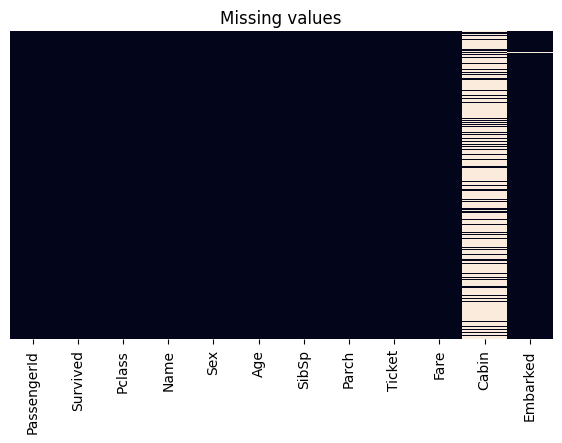

In [ ]:
# TODO
# 1. build a dictionary mean_ages mapping each passenger class to the mean age within that class
# 2. complete impute_missing_age so that a missing age is replaced by the class mean
#    and an age that is already present is returned unchanged
# 3. apply it along axis 1 to the two columns Age and Pclass
# 4. redraw the missing value heatmap to confirm that the Age column is now complete

mean_ages = titanic_df.groupby("Pclass")["Age"].mean().to_dict()


def impute_missing_age(columns):
    age, p_class = columns
    return mean_ages[p_class] if pd.isnull(age) else age


titanic_df["Age"] = titanic_df[["Age", "Pclass"]].apply(impute_missing_age, axis=1)
plot("Missing values", sns.heatmap, titanic_df.isnull(), yticklabels=False, cbar=False)


In [ ]:
# TODO
# 1. drop the Cabin column, which is missing for most passengers, then drop the remaining
#    rows that still contain a missing value
# 2. one-hot encode Sex and Embarked with pd.get_dummies, passing drop_first=True,
#    and concatenate the result to the frame
# 3. drop Name, PassengerId, Ticket, Sex, and Embarked
# 4. display the first five rows of the processed frame
titanic_df.drop("Cabin", axis=1, inplace=True)
titanic_df.dropna(inplace=True)
dummies = pd.get_dummies(titanic_df[["Sex", "Embarked"]], drop_first=True)
titanic_df = pd.concat([titanic_df, dummies], axis=1)
titanic_df.drop(["Name", "PassengerId", "Ticket", "Sex", "Embarked"], axis=1, inplace=True)
titanic_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


**ANSWER B2.** Explain why `drop_first=True` is used when the categorical columns are encoded,
and what would go wrong if all of the indicator columns were retained.

drop_first=True removes one indicator per categorical variable to avoid the dummy-variable trap. If all levels were kept, the indicator columns for a variable would sum to exactly 1 in every row, which is a perfect linear combination of the model's intercept column. The design matrix would then be rank-deficient (singular), so XᵀX cannot be inverted and the coefficients are no longer uniquely identifiable — infinitely many weight vectors give the identical fit. In practice scikit-learn's regularised solver would still return numbers, but they would be arbitrarily split between the redundant columns and therefore uninterpretable and unstable across runs.

Dropping one level costs no information: the omitted category becomes the reference level, absorbed into the intercept, and each retained coefficient is read as the effect relative to that reference. Here Sex_male is the effect of being male relative to female, and Embarked_Q/Embarked_S are relative to Cherbourg.

### TASK B3. Fitting and evaluating the classifier

Scale `Age` and `Fare` to the unit interval before fitting, so that the two columns of large
numerical range do not dominate the optimisation. Fix `random_state` in the split so that your
result is reproducible.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import minmax_scale

# TODO
# 1. rescale the Age and Fare columns with minmax_scale
# 2. separate the predictors X from the target y, which is the Survived column
# 3. split into training and test sets with test_size=0.3 and a fixed random_state
# 4. fit a LogisticRegression model and predict on the test set
# 5. print the classification report and the confusion matrix
titanic_df[["Age", "Fare"]] = minmax_scale(titanic_df[["Age", "Fare"]])
X = titanic_df.drop("Survived", axis=1)
y = titanic_df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
logreg = LogisticRegression(max_iter=1000).fit(X_train, y_train)
y_pred = logreg.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83       167
           1       0.72      0.72      0.72       100

    accuracy                           0.79       267
   macro avg       0.78      0.78      0.78       267
weighted avg       0.79      0.79      0.79       267

[[139  28]
 [ 28  72]]


In [ ]:
for rs in [0, 1, 42]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=rs)
    m = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
    print(rs, round((m.predict(Xte) == yte).mean() * 100, 2))

0 76.62
1 77.92
42 74.89


### TASK B4. Interpretation

Answer in the cell below.

1. Write out the confusion matrix you obtained and label the four entries as true positives, false
   positives, true negatives, and false negatives.
2. Define precision and recall in words, and compute both by hand for the survivor class from your
   confusion matrix. Confirm that your values match the classification report.
3. Rerun the split with three different values of `random_state` and record the accuracy each time.
   Comment on the spread and on what it implies about reporting a single accuracy figure.

**ANSWER B4**

1. The confusion matrix obtained (positive class = survived, 1) was
	Predicted 0	Predicted 1
Actual 0	139 → TN	28 → FP
Actual 1	28 → FN	72 → TP
2. Precision is the reliability of a positive prediction: of all the passengers the model claimed would survive, the fraction that actually did. Recall (sensitivity) is the coverage of the positive class: of all the passengers who actually survived, the fraction the model successfully found. Precision = TP/(TP+FP) = 72/(72+28) = 72/100 = 0.72
Recall = TP/(TP+FN) = 72/(72+28) = 72/100 = 0.72 Both match the classification report's row for class 1 exactly (0.72 / 0.72, F1 = 0.72). They coincide here only because FP happens to equal FN (both 28), which is a coincidence of this particular split, not a general property.
3. 0 76.62
1 77.92
42 74.89

---
## Program 2. Logistic regression by gradient descent, compared with `scikit-learn`

### Aim

To implement logistic regression through gradient descent on the log-likelihood, and to compare its
accuracy with the library implementation on the Pima diabetes dataset.

### Theory

$$
\newcommand{\vect}{\mathbf}
\text{Log-likelihood}, \quad LL = \sum_{i=1}^{m} y_i \log(p_i) + (1-y_i)\log(1-p_i)
$$

where

$$
p_i = p(\vect{x}_i, \vect{w}) = \frac{1}{1+e^{-\vect{w}^T\vect{x}_i}}
$$

Here $\vect{w} = (w_0, w_1, \dots, w_n)$ is the weight vector and
$\vect{x}_i = (1, x_{i1}, x_{i2}, \dots, x_{in})$ is the $i$th input vector, the leading unit
entry accounting for the intercept.

The weights are chosen so that

$$
\max_{\vect{w}} LL = \min_{\vect{w}} (-LL)
$$

The gradient of the negative log-likelihood takes the compact form

$$
\frac{d(-LL)}{d\vect{w}} = \sum_{i=1}^{m}(p_i-y_i)\,\vect{x}_i = (\vect{p}-\vect{y})^T X
$$

so that the update step of gradient descent is

$$
\vect{w} := \vect{w} - \alpha\,(\vect{p}-\vect{y})^T X
$$

where $\alpha$ is the learning rate.

### TASK B5. Implementing the classifier

Complete the class below. No optimisation routine from a library may be used.

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
class LogitRegression:
    """Binary logistic regression trained by full batch gradient descent."""

    def __init__(self, learning_rate, iterations):
        self.learning_rate = learning_rate
        self.iterations = iterations

    def p(self, X):
        return 1 / (1 + np.exp(-(X @ self.w)))

    def fit(self, X, y):
        m, n = X.shape
        X = np.hstack([np.ones((m, 1)), X])
        y = y.squeeze()
        self.w = np.zeros(n + 1)
        for _ in range(self.iterations):
            self.w -= self.learning_rate * ((self.p(X) - y) @ X) / m
        return self

    def predict(self, X):
        m = X.shape[0]
        X = np.hstack([np.ones((m, 1)), X])
        return (self.p(X) >= 0.5).astype(int)

In [ ]:
from sklearn.preprocessing import minmax_scale
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

diabetes_df = pd.read_csv("diabetes.csv")
X = minmax_scale(diabetes_df.iloc[:, :-1].values)
y = diabetes_df.iloc[:, -1:].values.reshape(-1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=6
)
print(X_train.shape, X_test.shape)

(512, 8) (256, 8)


In [ ]:
def compute_accuracy(model, X_test, y_test):
    y_hat = model.predict(X_test)
    return (y_hat == y_test).mean() * 100


# TODO: fit both your own LogitRegression, with learning_rate=0.1 and iterations=1000,
# and the library LogisticRegression, then print the test accuracy of each
models = [
    LogitRegression(learning_rate=0.1, iterations=1000),
    LogisticRegression(),
]

for m in models:
    m.fit(X_train, y_train)
    print(type(m).__name__, round(compute_accuracy(m, X_test, y_test), 2))


LogitRegression 74.22
LogisticRegression 78.91


### TASK B6. Effect of the learning rate

Train your implementation with learning rates of 0.001, 0.01, 0.1, and 1.0, holding the number of
iterations fixed at 1000. Tabulate the test accuracy against the learning rate and comment in two
or three sentences on what you observe at the two extremes.

In [ ]:
# TODO : loop over the four learning rates and report the test accuracy of each
for lr in [0.001, 0.01, 0.1, 1.0]:
    m = LogitRegression(learning_rate=lr, iterations=1000).fit(X_train, y_train)
    print(lr, round(compute_accuracy(m, X_test, y_test), 2))

0.001 67.58
0.01 67.58
0.1 74.22
1.0 77.34


**ANSWER B6.**
0.001 67.58
0.01 67.58
0.1 74.22
1.0 77.34
At 0.001 and 0.01 the steps are too small for 1000 iterations, so the weights barely move from zero and the model predicts only the majority class - 67.58% is the no-skill baseline. Accuracy improves as the rate rises, reaching 77.34% at 1.0, near scikit-learn's 78.91%. A much larger rate would overshoot and oscillate instead of converging.